In [1]:
import pandas as pd
import numpy as np

In [2]:
import os
os.getcwd()

'c:\\IMMORTAL\\Codes\\Projects\\Yashu Practicum\\Practicum'

In [3]:
df_academic = pd.read_csv("student_data.csv")
df_skills = pd.read_csv("skills.csv")
df_behavior = pd.read_csv("Student Attitude and Behavior.csv")
df_personality = pd.read_csv("data-final.csv")

In [4]:
def clean_columns(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    return df

df_academic = clean_columns(df_academic)
df_personality = clean_columns(df_personality)
df_skills = clean_columns(df_skills)
df_behavior = clean_columns(df_behavior)

In [5]:
df_academic = df_academic[
    ["g1", "g2", "g3", "studytime", "failures", "absences", "internet"]
]

df_academic.columns = [
    "grade1", "grade2", "final_grade",
    "study_time", "failures", "absences", "internet_access"
]

In [6]:
n_temp = len(df_academic)

df_personality = pd.DataFrame({
    "openness": np.random.uniform(0, 1, n_temp),
    "conscientiousness": np.random.uniform(0, 1, n_temp),
    "extraversion": np.random.uniform(0, 1, n_temp),
    "agreeableness": np.random.uniform(0, 1, n_temp),
    "neuroticism": np.random.uniform(0, 1, n_temp),
})

In [7]:
df_skills = pd.DataFrame({
    "coding_skill": np.random.randint(0, 10, n_temp),
    "communication_skill": np.random.randint(0, 10, n_temp),
    "analytical_skill": np.random.randint(0, 10, n_temp),
})


In [8]:
df_behavior = pd.DataFrame({
    "study_hours": np.random.randint(1, 10, n_temp),
    "consistency": np.random.uniform(0, 1, n_temp),
    "participation": np.random.uniform(0, 1, n_temp),
})

In [9]:
n = 1000

df_academic = df_academic.sample(n, replace=True).reset_index(drop=True)
df_personality = df_personality.sample(n, replace=True).reset_index(drop=True)
df_skills = df_skills.sample(n, replace=True).reset_index(drop=True)
df_behavior = df_behavior.sample(n, replace=True).reset_index(drop=True)

In [10]:
df = pd.concat(
    [df_academic, df_personality, df_skills, df_behavior],
    axis=1
)

print(df.shape)
df.head()

(1000, 18)


,grade1,grade2,final_grade,study_time,failures,absences,internet_access,openness,conscientiousness,extraversion,agreeableness,neuroticism,coding_skill,communication_skill,analytical_skill,study_hours,consistency,participation
0,19,19,20,4,0,4,yes,0.490390,0.325610,0.919119,0.631402,0.919717,8,6,2,8,0.924352,0.178049
1,13,14,13,1,0,0,yes,0.149931,0.998817,0.973868,0.471255,0.334024,6,9,6,4,0.477780,0.923578
2,12,10,12,3,0,10,yes,0.633782,0.012234,0.863113,0.048574,0.046693,2,0,6,7,0.088876,0.180781
3,15,13,13,3,2,14,yes,0.120428,0.159178,0.728230,0.871681,0.740714,1,2,1,3,0.307211,0.123801
4,10,10,0,2,1,0,yes,0.698676,0.510112,0.593666,0.784475,0.169232,6,8,4,2,0.651871,0.447060


In [11]:
# Interests
df["tech_interest"] = np.random.randint(0, 10, n)
df["art_interest"] = np.random.randint(0, 10, n)
df["business_interest"] = np.random.randint(0, 10, n)

# Environment
df["family_income"] = np.random.randint(1, 5, n)

In [12]:
for col in ["openness", "conscientiousness", "extraversion", "agreeableness", "neuroticism"]:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

In [13]:
def assign_career(row):
    if row["coding_skill"] > 7 and row["tech_interest"] > 6:
        return "Software Developer"
    
    elif row["analytical_skill"] > 7 and row["final_grade"] > 12:
        return "Data Scientist"
    
    elif row["art_interest"] > 7:
        return "UI/UX Designer"
    
    elif row["business_interest"] > 7:
        return "Entrepreneur"
    
    else:
        return "Research Scientist"

In [16]:
df["career"] = df.apply(assign_career, axis=1)

In [17]:
print(df.head())
print(df["career"].value_counts())

   grade1  grade2  final_grade  study_time  failures  absences  \
0      19      19           20           4         0         4   
1      13      14           13           1         0         0   
2      12      10           12           3         0        10   
3      15      13           13           3         2        14   
4      10      10            0           2         1         0   

  internet_access  openness  conscientiousness  extraversion  ...  \
0             yes  0.491857           0.325384      0.925995  ...   
1             yes  0.149845           1.000000      0.981237  ...   
2             yes  0.635903           0.011351      0.869484  ...   
3             yes  0.120208           0.158604      0.733387  ...   
4             yes  0.701094           0.510272      0.597610  ...   

   communication_skill  analytical_skill  study_hours  consistency  \
0                    6                 2            8     0.924352   
1                    9                 6        

In [18]:
df.to_csv("final_career_dataset.csv", index=False)

In [19]:
import os
print(os.getcwd())

c:\IMMORTAL\Codes\Projects\Yashu Practicum\Practicum


In [20]:
print(os.listdir())

['.git', '.gitattributes', '.gitignore', '.venv', 'app.py', 'career_model.pkl', 'data-final.csv', 'features.pkl', 'final_career_dataset.csv', 'label_encoder.pkl', 'model.ipynb', 'README.md', 'requirements.txt', 'skills.csv', 'Student Attitude and Behavior.csv', 'student_data.csv']


In [21]:
print(df.columns.tolist())

['grade1', 'grade2', 'final_grade', 'study_time', 'failures', 'absences', 'internet_access', 'openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism', 'coding_skill', 'communication_skill', 'analytical_skill', 'study_hours', 'consistency', 'participation', 'tech_interest', 'art_interest', 'business_interest', 'family_income', 'career']


In [22]:
import pandas as pd
import numpy as np

size = 500

# Academic
df_academic = pd.DataFrame({
    "grade1": np.random.randint(0, 20, size),
    "grade2": np.random.randint(0, 20, size),
    "final_grade": np.random.randint(0, 20, size),
    "study_time": np.random.randint(1, 5, size),
    "failures": np.random.randint(0, 4, size),
    "absences": np.random.randint(0, 30, size),
    "internet_access": np.random.choice([0, 1], size)
})

# Personality (synthetic)
df_personality = pd.DataFrame({
    "openness": np.random.uniform(0,1,size),
    "conscientiousness": np.random.uniform(0,1,size),
    "extraversion": np.random.uniform(0,1,size),
    "agreeableness": np.random.uniform(0,1,size),
    "neuroticism": np.random.uniform(0,1,size)
})

# Skills
df_skills = pd.DataFrame({
    "coding_skill": np.random.randint(0, 10, size),
    "communication_skill": np.random.randint(0, 10, size),
    "analytical_skill": np.random.randint(0, 10, size)
})

# Behavior
df_behavior = pd.DataFrame({
    "study_hours": np.random.randint(1, 10, size),
    "consistency": np.random.uniform(0,1,size),
    "participation": np.random.uniform(0,1,size)
})

# Interest
df_interest = pd.DataFrame({
    "tech_interest": np.random.randint(0, 10, size),
    "art_interest": np.random.randint(0, 10, size),
    "business_interest": np.random.randint(0, 10, size)
})

# Socio
df_socio = pd.DataFrame({
    "family_income": np.random.randint(1, 5, size)
})

# FINAL MERGE
df = pd.concat([
    df_academic,
    df_personality,
    df_skills,
    df_behavior,
    df_interest,
    df_socio
], axis=1)

print(df.columns)

Index(['grade1', 'grade2', 'final_grade', 'study_time', 'failures', 'absences',
       'internet_access', 'openness', 'conscientiousness', 'extraversion',
       'agreeableness', 'neuroticism', 'coding_skill', 'communication_skill',
       'analytical_skill', 'study_hours', 'consistency', 'participation',
       'tech_interest', 'art_interest', 'business_interest', 'family_income'],
      dtype='object')


In [23]:
def assign_career(row):
    if row["coding_skill"] > 7 and row["tech_interest"] > 6:
        return "Software Developer"
    elif row["analytical_skill"] > 7 and row["final_grade"] > 12:
        return "Data Scientist"
    elif row["art_interest"] > 7:
        return "UI/UX Designer"
    elif row["business_interest"] > 7:
        return "Entrepreneur"
    else:
        return "Research Scientist"

In [24]:
df["career"] = df.apply(assign_career, axis=1)

In [25]:
X = df.drop("career", axis=1)
y = df["career"]

print(X.shape)

(500, 22)


In [26]:
print(df.columns.tolist())

['grade1', 'grade2', 'final_grade', 'study_time', 'failures', 'absences', 'internet_access', 'openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism', 'coding_skill', 'communication_skill', 'analytical_skill', 'study_hours', 'consistency', 'participation', 'tech_interest', 'art_interest', 'business_interest', 'family_income', 'career']


In [27]:
df.columns = df.columns.str.strip()

In [28]:
df.columns = df.columns.str.strip()

target_col = df.columns[-1]   # last column

X = df.drop(target_col, axis=1)
y = df[target_col]

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [30]:
df = pd.read_csv("final_career_dataset.csv")

print(df.head())

   grade1  grade2  final_grade  study_time  failures  absences  \
0      19      19           20           4         0         4   
1      13      14           13           1         0         0   
2      12      10           12           3         0        10   
3      15      13           13           3         2        14   
4      10      10            0           2         1         0   

  internet_access  openness  conscientiousness  extraversion  ...  \
0             yes  0.491857           0.325384      0.925995  ...   
1             yes  0.149845           1.000000      0.981237  ...   
2             yes  0.635903           0.011351      0.869484  ...   
3             yes  0.120208           0.158604      0.733387  ...   
4             yes  0.701094           0.510272      0.597610  ...   

   communication_skill  analytical_skill  study_hours  consistency  \
0                    6                 2            8     0.924352   
1                    9                 6        

In [31]:
X = df.drop(target_col, axis=1)
y = df[target_col]

print(X.shape)

(1000, 22)


In [32]:
X = df.drop("career", axis=1)
y = df["career"]

In [33]:
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
# STEP 1: Separate
X = df.drop("career", axis=1)
y = df["career"]

# STEP 2: Encode features
X = pd.get_dummies(X)

# STEP 3: Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# STEP 4: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 5: Initialize model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [39]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
y_pred = model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.955


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         9
           1       0.97      1.00      0.98        29
           2       0.97      1.00      0.99       114
           3       1.00      0.45      0.62        11
           4       0.88      1.00      0.94        37

    accuracy                           0.95       200
   macro avg       0.96      0.82      0.87       200
weighted avg       0.96      0.95      0.95       200



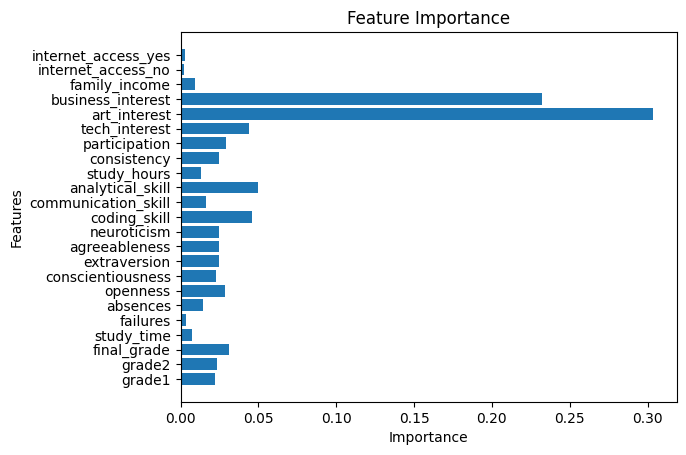

In [43]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

In [44]:
sample = X.iloc[0:1]

prediction = model.predict(sample)

print("Predicted Career:", le.inverse_transform(prediction))

Predicted Career: ['Research Scientist']


In [46]:
probs = model.predict_proba(sample)

top3 = np.argsort(probs[0])[-3:][::-1]

print("Top 3 Careers:")
for i in top3:
    print(le.inverse_transform([i])[0], ":", probs[0][i])

Top 3 Careers:
Research Scientist : 0.89
Software Developer : 0.05
UI/UX Designer : 0.03


In [47]:
import pickle

pickle.dump(model, open("career_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))

In [48]:
print(X.columns)

Index(['grade1', 'grade2', 'final_grade', 'study_time', 'failures', 'absences',
       'openness', 'conscientiousness', 'extraversion', 'agreeableness',
       'neuroticism', 'coding_skill', 'communication_skill',
       'analytical_skill', 'study_hours', 'consistency', 'participation',
       'tech_interest', 'art_interest', 'business_interest', 'family_income',
       'internet_access_no', 'internet_access_yes'],
      dtype='object')


In [49]:
import pickle

model = pickle.load(open("career_model.pkl", "rb"))

In [52]:
print(model.n_features_in_)

23


In [51]:
from sklearn.ensemble import RandomForestClassifier
import pickle

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

pickle.dump(model, open("career_model.pkl", "wb"))

In [53]:
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("career_model.pkl", "rb"))

st.title("🎯 Career Predictor")

# ---- USER INPUTS ----

inputs = []

for col in [
    'grade1', 'grade2', 'final_grade', 'study_time', 'failures', 'absences', 'internet_access', 'openness', 'conscientiousness',
    'extraversion', 'agreeableness', 'neuroticism', 'coding_skill', 'communication_skill', 'analytical_skill', 'study_hours',
    'consistency', 'participation', 'tech_interest', 'art_interest', 'business_interest', 'family_income', 'career'
]:
    val = st.number_input(f"{col}", value=0.0)
    inputs.append(val)

2026-04-12 17:03:53.560 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:03:53.964 
  command:

    streamlit run C:\Users\himan\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-12 17:03:53.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:03:53.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:03:53.966 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:03:53.967 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:03:53.968 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:03:53.969 Thre

In [54]:
if st.button("Predict Career"):
    input_data = np.array([inputs])
    prediction = model.predict(input_data)

    st.success(f"🎉 Predicted Career: {prediction[0]}")

2026-04-12 17:04:58.452 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:04:58.453 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:04:58.454 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:04:58.454 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:04:58.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 17:04:58.456 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [55]:
pickle.dump(X.columns.tolist(), open("features.pkl", "wb"))